# Shared latent rollout across mechanical datasets

Train one shared 2D autoencoder and a fixed-history latent propagator across Reid, low-temperature de Pablo, and mixed-temperature de Pablo. Dynamic coordinates use normalized [-1,1] boxes; the AE encoder/decoder explicitly receives the recoverable physical reference graph. The propagator uses z(1), z(5), the current latent state, and a pooled static reference-graph context. It receives no dataset label, explicit temperature, frame index, or progress variable.

In [1]:
%matplotlib inline
import os, sys
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT/'src'/'lss').exists(): PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT/'src') not in sys.path: sys.path.insert(0, str(PROJECT_ROOT/'src'))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lss.latent.analysis import label_evaluation_sources
from lss.latent.experiment import latent_experiment_cache_key, run_latent_experiment, seed_everything
from lss.latent.simulation import pearson_r, r2_score
from lss.plotting import PAPER_COLORS, apply_editorial_style, dataset_color, style_axes
from lss.utils import resolve_device
apply_editorial_style()
PAPER_DPI = 180
PAPER_FIGSIZE = (5.4, 4.2)
PAPER_WIDE_FIGSIZE = (10.8, 4.2)
DIVERSE_TRAINING_COLOR = PAPER_COLORS['green']
LIMITED_TRAINING_COLOR = PAPER_COLORS['purple']
plt.rcParams.update({'figure.dpi': PAPER_DPI, 'savefig.dpi': 400})
DEVICE = resolve_device('auto')
DEVICE

/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

## Configuration

In [2]:
SEED = 3456345
FORCE_TRAIN = True
TRAIN_PER_SOURCE = 15
VAL_PER_SOURCE = 15
TRAIN_STEPS_PER_SIM = 100
MAX_EPOCHS = 30
PATIENCE = 6
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
LATENT_DIM = 2
# Real Reid endpoint p-ratio is ill-conditioned before appreciable strain develops.
# Start at frame 5 and resolve the 0–50 region densely with a trajectory fit.
EARLY_ROLLOUT_STEPS = [5, 10, 25, 50]
ROLLOUT_STEPS = [25, 50, 75, 100, 125, 150, 175, 199]
PLOT_ROLLOUT_STEPS = sorted(set([*EARLY_ROLLOUT_STEPS, *ROLLOUT_STEPS]))
DATASETS = {
    'reid': {'label': 'Reid', 'path': PROJECT_ROOT/'data'/'reid_200_frames.pt'},
    'depablo_low_temp': {'label': 'de Pablo low-T', 'path': PROJECT_ROOT/'data'/'depablo-near-zero-temp.pt'},
    'depablo_mixed_temp': {'label': 'de Pablo mixed-T', 'path': PROJECT_ROOT/'data'/'depablo-10k-mix-temp.pt'},
}
for spec in DATASETS.values(): assert spec['path'].exists(), spec['path']
OUTPUT = PROJECT_ROOT/'notebooks'/'results'/'06b_mixed_dataset_shared_latent_rollout_boxnorm'
OUTPUT.mkdir(parents=True, exist_ok=True)
MODEL_CONFIG = {
    'latent_dim': LATENT_DIM, 'latent_tokens': 32, 'hidden_size': 96,
    'batch_graphs': 32,
    'coordinate_normalization': 'position_normalization',
    'reference_context_mode': 'physical',
    'edge_mode': 'compact_stored',
    'edge_feature_schema': 'compact_unique_edge_changes_v1',
}
MODEL_CACHE = OUTPUT/'model_compact_edges_v5_matched_budget_history_z1_z5.pt'
print({'device': str(DEVICE), 'training_networks': TRAIN_PER_SOURCE*len(DATASETS), 'training_steps_per_trajectory': TRAIN_STEPS_PER_SIM, 'cache': str(MODEL_CACHE)})

{'device': 'cuda', 'training_networks': 45, 'cache': '/home/alexz/Documents/course_project/notebooks/results/06b_mixed_dataset_shared_latent_rollout_boxnorm/model_static_context_dynamic_changes_v3_history_z1_z5.pt'}


## Shared autoencoder and propagator

In [3]:
ae_config = {
    'latent_dim': LATENT_DIM, 'latent_tokens': MODEL_CONFIG['latent_tokens'],
    'hidden_size': MODEL_CONFIG['hidden_size'], 'model': 'attention',
    'edge_feature_dim': 4, 'target_mode': 'normalized_delta', 'node_feature_mode': 'normalized_delta',
    'max_train_frames_per_sim': TRAIN_STEPS_PER_SIM + 1,
    'val_frame_skip': 1, 'max_val_frames_per_sim': TRAIN_STEPS_PER_SIM + 1,
    'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY,
    'balance_sources': False, 'mix_sources': True,
}
propagator_config = {
    'max_train_transitions_per_sim': TRAIN_STEPS_PER_SIM,
    'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY,
    'hidden_size': 128, 'objective': 'fixed_history_one_step',
    'model': 'fixed_velocity_residual_mlp', 'loss': 'delta', 'step_stride': 1,
    'fixed_observed_frames': (1, 5), 'multistep_horizons': [1],
    'mix_sources': True, 'balance_sources': False,
    'train_trajectories_per_source': {key: TRAIN_PER_SOURCE for key in DATASETS},
    'val_trajectories_per_source': {key: VAL_PER_SOURCE for key in DATASETS},
    'use_static_context': True, 'context_dim': 16,
    'context_pool': 'mean', 'rollout_eval_every_epoch': True, 'rollout_eval_horizons': [100],
    'rollout_eval_sims_per_source': VAL_PER_SOURCE,
}
experiment_config = {
    'ae_config': ae_config, 'propagator_config': propagator_config,
    'dataset_name': 'mixed_sources_shared', 'split_seed': SEED, 'split_stratify_temperature': False,
    'min_train_p_ratio': None, 'device': str(DEVICE), 'pos_dim': 2, 'batch_graphs': MODEL_CONFIG['batch_graphs'],
    'frame_skip': 1, 'train_frame_start_order': 0,
    'edge_mode': MODEL_CONFIG['edge_mode'],
    'coordinate_normalization': MODEL_CONFIG['coordinate_normalization'],
    'reference_context_mode': MODEL_CONFIG['reference_context_mode'],
    'edge_feature_schema': MODEL_CONFIG['edge_feature_schema'],
    'rollout_steps_grid': ROLLOUT_STEPS,
    'rollout_final_eval_sims_per_source': 30,
    'early_stop_min_delta': 1e-5, 'should_rollout': True, 'should_train_propagator': True,
    'force_train': FORCE_TRAIN, 'cache_path': str(MODEL_CACHE),
    'cache_require_matching_config': True, 'model_seed': SEED, 'repeat_idx': 1,
}
mixture = [{'name': key, 'label': spec['label'], 'path': str(spec['path']), 'train_count': TRAIN_PER_SOURCE, 'val_count': VAL_PER_SOURCE} for key,spec in DATASETS.items()]
source = {
    'dataset_name': 'mixed_sources_shared', 'source_name': 'three-source mixture', 'label': 'shared three-source fixed-history rollout',
    'path': str(next(iter(DATASETS.values()))['path']), 'dataset_mixture': mixture,
}
seed_everything(SEED)
result = run_latent_experiment(source, experiment_config, device=DEVICE)
display(result['split_info'])
display(result['ae_history'].tail()); display(result['dyn_history'].tail())


=== shared three-source fixed-history rollout ===
            source                                                                path  total  train  reserved_train_pool  val  test
              reid        /home/alexz/Documents/course_project/data/reid_200_frames.pt    102     15                   15   15    72
  depablo_low_temp /home/alexz/Documents/course_project/data/depablo-near-zero-temp.pt    200     15                   15   15   170
depablo_mixed_temp   /home/alexz/Documents/course_project/data/depablo-10k-mix-temp.pt    300     15                   15   15   270
source-mixed AE coverage: {'reid': {'trajectories': 15, 'frames': 3000}, 'depablo_low_temp': {'trajectories': 15, 'frames': 3000}, 'depablo_mixed_temp': {'trajectories': 15, 'frames': 3000}}
autoencoder
ae 0001 train=0.637814 val=0.594011 stale=0
ae 0002 train=0.41372 val=0.480876 stale=0
ae 0003 train=0.385315 val=0.473199 stale=0
ae 0004 train=0.367661 val=0.434565 stale=0
ae 0005 train=0.32126 val=0.395358 stal

,source,path,total,train,reserved_train_pool,val,test
0,reid,/home/alexz/Documents/course_project/data/reid...,102,15,15,15,72
1,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,200,15,15,15,170
2,depablo_mixed_temp,/home/alexz/Documents/course_project/data/depa...,300,15,15,15,270


,epoch,train_objective,val_objective,train_mse_norm,val_mse_norm,dataset,latent_dim,target_mode,hidden_size
5,6,0.298089,0.372403,0.298089,0.372403,shared three-source fixed-history rollout,2,normalized_delta,96
6,7,0.287929,0.360721,0.287929,0.360721,shared three-source fixed-history rollout,2,normalized_delta,96
7,8,0.283148,0.357339,0.283148,0.357339,shared three-source fixed-history rollout,2,normalized_delta,96
8,9,0.279994,0.363278,0.279994,0.363278,shared three-source fixed-history rollout,2,normalized_delta,96
9,10,0.277135,0.356268,0.277135,0.356268,shared three-source fixed-history rollout,2,normalized_delta,96


,epoch,train_loss,val_loss,train_dz_mse_norm,train_loss_raw,train_position_loss,val_dz_mse_norm,val_dz_mse_raw,val_position_loss,val_rollout_p_ratio_r2,...,dataset,latent_dim,target_mode,hidden_size,propagator_loss,propagator_objective,propagator_multistep_horizons,propagator_multistep_loss,propagator_step_stride,initial_velocity
2,3,1.061764,1.937031,1.061764,0.093517,0.0,1.937031,0.168467,0.0,0.005138,...,shared three-source fixed-history rollout,2,normalized_delta,96,delta,fixed_history_one_step,[1],all_steps_plus_optional_decoded_endpoint,1,zero
3,4,1.032257,1.901674,1.032257,0.090928,0.0,1.901674,0.164840,0.0,-0.025661,...,shared three-source fixed-history rollout,2,normalized_delta,96,delta,fixed_history_one_step,[1],all_steps_plus_optional_decoded_endpoint,1,zero
4,5,1.016453,1.891493,1.016453,0.089479,0.0,1.891493,0.163406,0.0,-0.433569,...,shared three-source fixed-history rollout,2,normalized_delta,96,delta,fixed_history_one_step,[1],all_steps_plus_optional_decoded_endpoint,1,zero
5,6,0.998000,1.871895,0.998000,0.087865,0.0,1.871895,0.161291,0.0,-0.039322,...,shared three-source fixed-history rollout,2,normalized_delta,96,delta,fixed_history_one_step,[1],all_steps_plus_optional_decoded_endpoint,1,zero
6,7,0.993498,1.874234,0.993498,0.087448,0.0,1.874234,0.161659,0.0,0.061110,...,shared three-source fixed-history rollout,2,normalized_delta,96,delta,fixed_history_one_step,[1],all_steps_plus_optional_decoded_endpoint,1,zero


## Latent dimensionality and mechanics correlation heatmaps

Notebook 06 establishes which mechanics the shared latent coordinates track. Here the one-network and multi-network representations are compared directly. A richer representation should occupy both latent dimensions (higher effective rank and a healthier second covariance mode), while distinct `z0` and `z1` correlation profiles show that the coordinates carry complementary—not duplicated—mechanical information. Raw coordinate correlation is retained only as an intuitive, basis-dependent diagnostic.


Evaluating validation-selected early Real Reid trajectory p-ratio...
Equal-weight mean of absolute within-dataset latent-summary correlations: one versus more training networks per source.


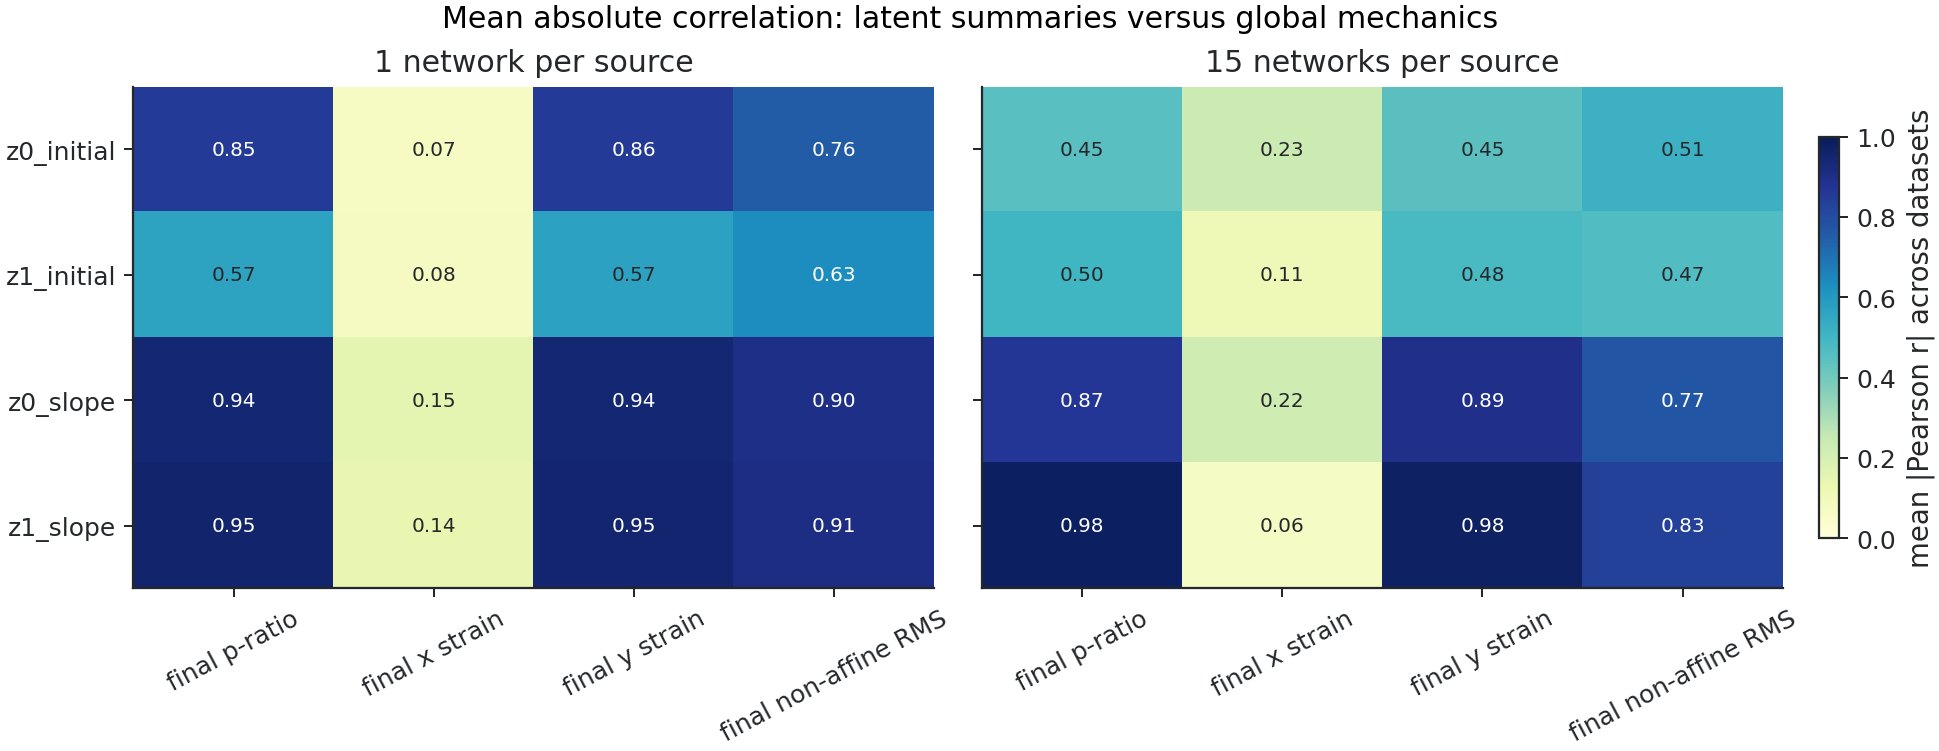

Equal-weight mean across datasets of absolute within-trajectory latent–mechanics correlations. Different z0 and z1 rows indicate coordinate specialization.


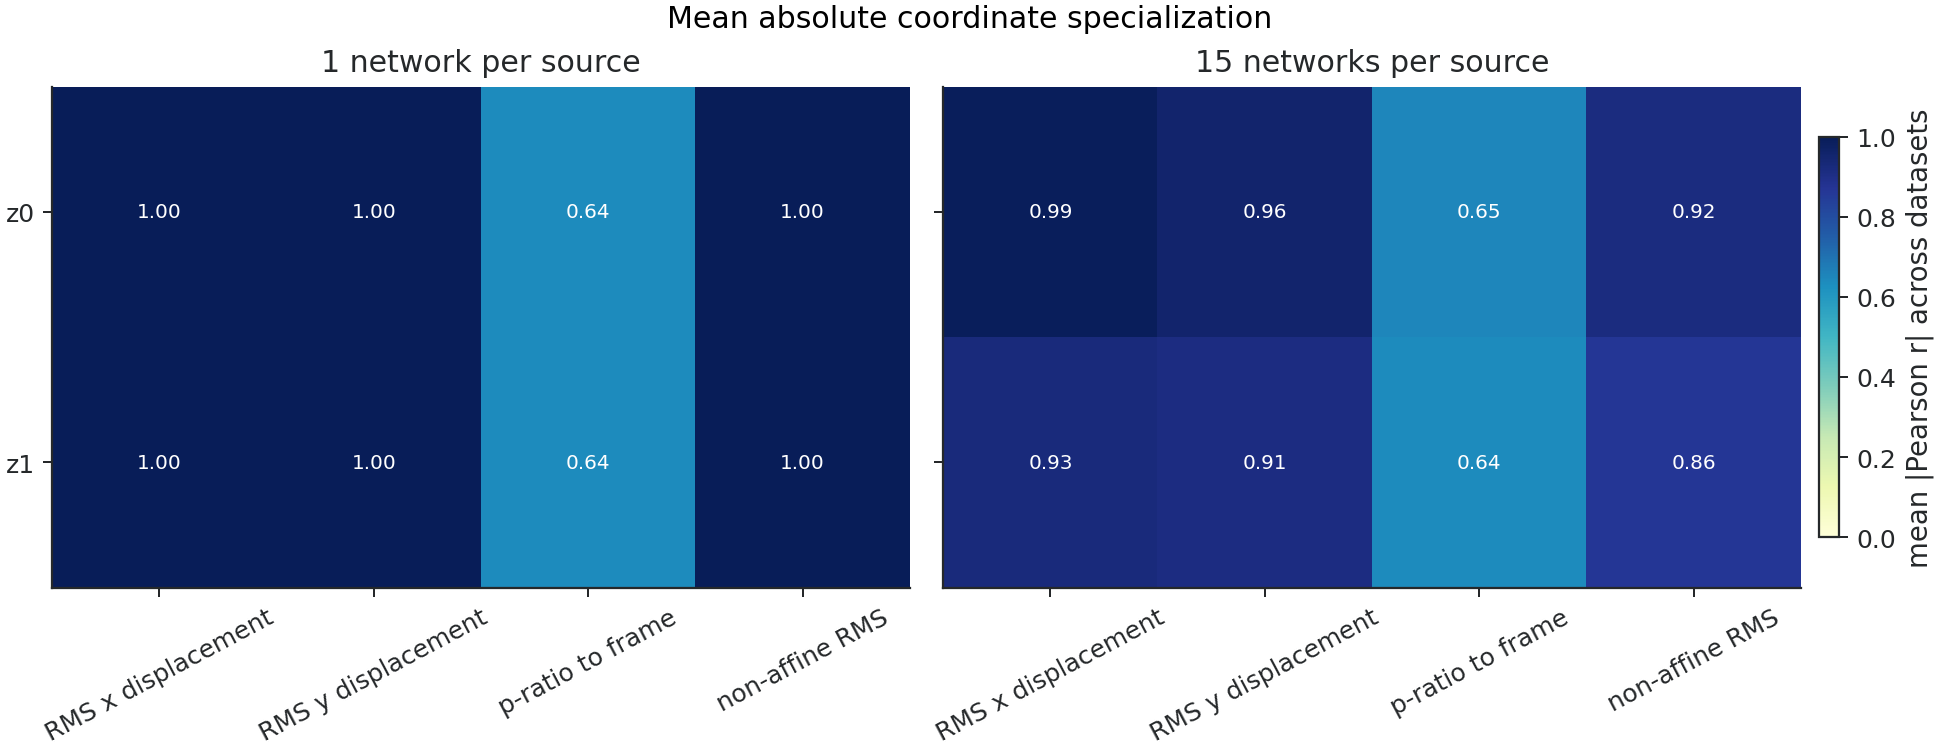

Larger profile differences mean z0 and z1 correlate with frame mechanics in different ways.


,training_regime,group,mean_abs_z0_z1_profile_difference,descriptors_compared
0,1 network per source,combined,0.000,4
1,15 networks per source,combined,0.043,4


,training_regime,dataset,n_frames,absolute_z0_z1_r,pc2_variance_fraction,singular_value_ratio_s2_over_s1,effective_rank
0,1 network per source,all datasets,12000,0.993,0.001,0.024,1.005
1,1 network per source,Reid,6000,1.000,0.000,0.006,1.000
2,1 network per source,de Pablo low-T,6000,0.977,0.002,0.047,1.016
3,15 networks per source,all datasets,4590,0.418,0.252,0.580,1.758
4,15 networks per source,Reid,1530,0.438,0.159,0.434,1.548
5,15 networks per source,de Pablo low-T,1530,0.263,0.332,0.704,1.888
6,15 networks per source,de Pablo mixed-T,1530,0.524,0.234,0.552,1.722


Held-out coordinate coupling and effective dimensionality. Lower |r| and effective rank nearer 2 indicate richer two-dimensional use.


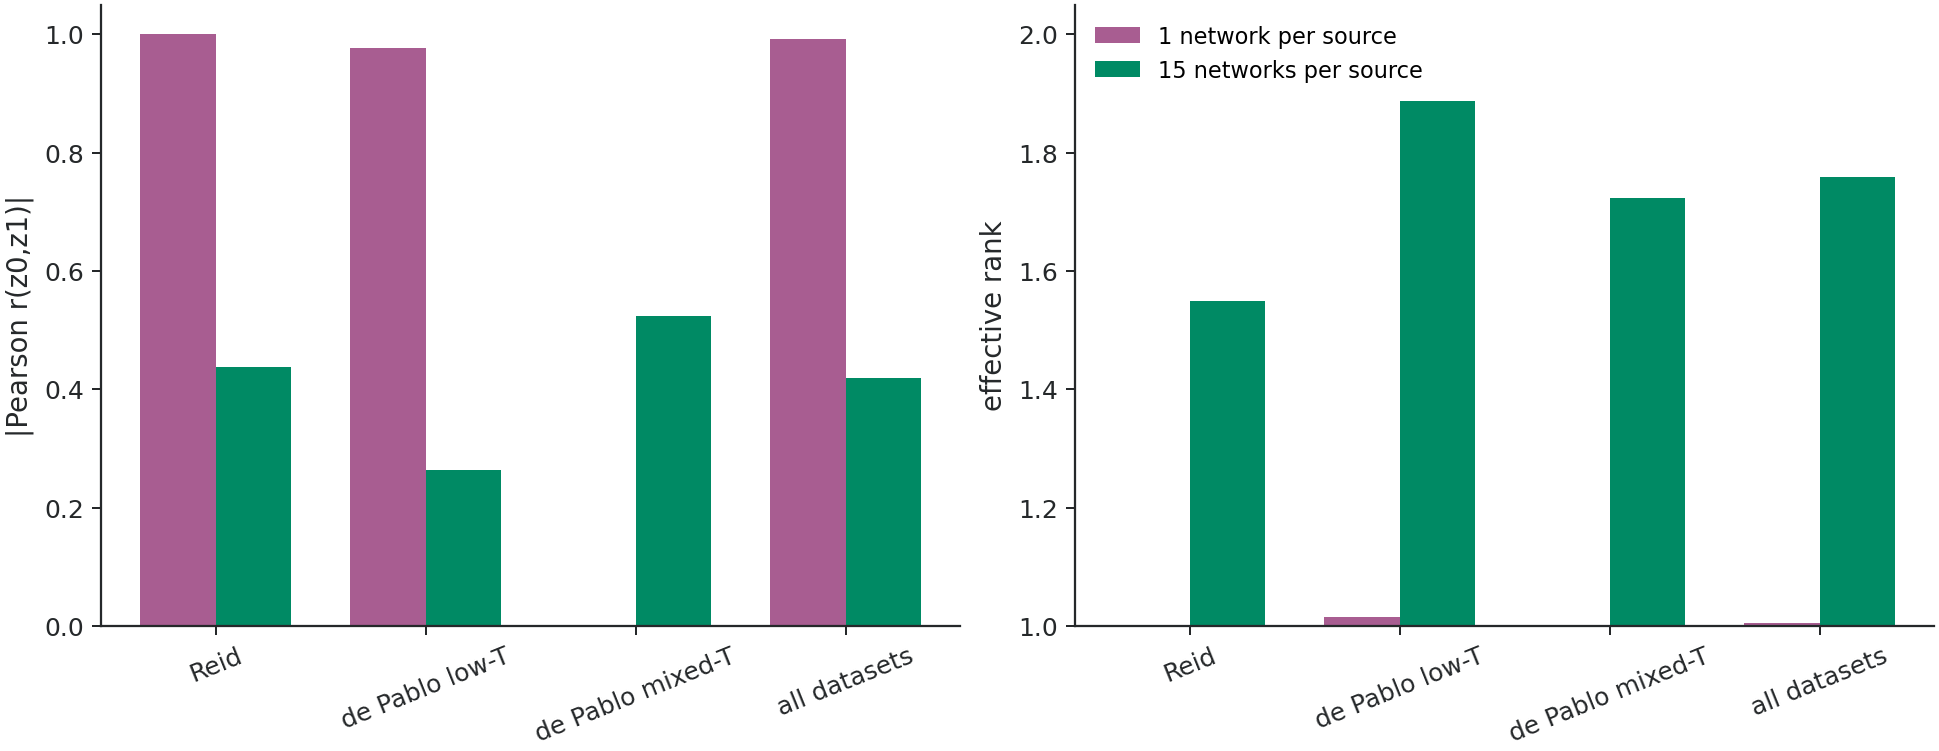

In [4]:
from lss.latent.training import encode_frame_latent
from lss.latent.experiment import ground_truth_p_ratio
from lss.latent.analysis import _frame_descriptor_row, _trajectory_p_ratio_columns
from graph_utils import directional_side_indices_from_box

DIAGNOSTIC_NETWORKS_PER_SOURCE = 30
DIAGNOSTIC_FRAME_STRIDE = 4
from lss.latent.experiment import evaluate_autoencoder_reconstruction_horizons, evaluate_rollout_horizons

# Evaluate missing near-origin horizons without invalidating or retraining the cached models.
existing_test_steps = set(result['rollout_rows'].query("split == 'test'").rollout_steps.astype(int))
missing_early_steps = [step for step in EARLY_ROLLOUT_STEPS if step not in existing_test_steps]
if missing_early_steps:
    early_rollout_rows, early_rollout_stats = evaluate_rollout_horizons(
        result['ae'], result['dyn'], result['test_data'], result['latent_stats'],
        experiment_config=result['params'], normalizers=result['normalizers'], dataset=result['label'],
        split_name='test', rollout_steps=missing_early_steps, device=DEVICE,
    )
    early_ae_rows, early_ae_stats = evaluate_autoencoder_reconstruction_horizons(
        result['ae'], result['test_data'], experiment_config=result['params'], normalizers=result['normalizers'],
        dataset=result['label'], split_name='test', rollout_steps=missing_early_steps, device=DEVICE,
    )
    result['rollout_rows'] = pd.concat([result['rollout_rows'], early_rollout_rows], ignore_index=True)
    result['rollout_stats'] = pd.concat([result['rollout_stats'], early_rollout_stats], ignore_index=True)
    result['ae_reconstruction_rows'] = pd.concat([result['ae_reconstruction_rows'], early_ae_rows], ignore_index=True)
    result['ae_reconstruction_stats'] = pd.concat([result['ae_reconstruction_stats'], early_ae_stats], ignore_index=True)

# Real Reid's endpoint ratio is unstable before appreciable strain develops.
# Validation selected this cumulative side-strain/time fit; no model retraining is involved.
reid_early_cfg = {
    **result['params'], 'p_ratio_estimator': 'strain_gated_trajectory',
    'p_ratio_min_fit_frames': 4, 'p_ratio_min_driven_strain_range': 1e-4,
    'p_ratio_side_quantile': .10,
}
reid_early_cache_key = latent_experiment_cache_key(source, experiment_config) + '-reid-time-strain-full-v3'
reid_rollout_cache = OUTPUT/'heldout_reid_trajectory_rollout_rows.csv'
reid_ae_cache = OUTPUT/'heldout_reid_trajectory_autoencoder_rows.csv'
reid_rollout_raw = pd.read_csv(reid_rollout_cache) if reid_rollout_cache.exists() and not FORCE_TRAIN else pd.DataFrame()
reid_ae_raw = pd.read_csv(reid_ae_cache) if reid_ae_cache.exists() and not FORCE_TRAIN else pd.DataFrame()
reid_cache_matches = all(
    not frame.empty and 'evaluation_cache_key' in frame and frame.evaluation_cache_key.nunique() == 1
    and frame.evaluation_cache_key.iloc[0] == reid_early_cache_key
    and 'p_ratio_estimator' in frame and frame.p_ratio_estimator.nunique() == 1
    and frame.p_ratio_estimator.iloc[0] == 'strain_gated_trajectory'
    and set(PLOT_ROLLOUT_STEPS).issubset(set(frame.rollout_steps.astype(int)))
    for frame in [reid_rollout_raw, reid_ae_raw]
)
if not reid_cache_matches:
    print('Evaluating validation-selected early Real Reid trajectory p-ratio...')
    reid_test_data = [sim for sim in result['test_data'] if str(getattr(sim[0], 'source_name', '')) == 'reid']
    reid_rollout_raw, _ = evaluate_rollout_horizons(
        result['ae'], result['dyn'], reid_test_data, result['latent_stats'],
        experiment_config=reid_early_cfg, normalizers=result['normalizers'], dataset=result['label'],
        split_name='test', rollout_steps=PLOT_ROLLOUT_STEPS, device=DEVICE,
    )
    reid_ae_raw, _ = evaluate_autoencoder_reconstruction_horizons(
        result['ae'], reid_test_data, experiment_config=reid_early_cfg, normalizers=result['normalizers'],
        dataset=result['label'], split_name='test', rollout_steps=PLOT_ROLLOUT_STEPS, device=DEVICE,
    )
    reid_rollout_raw['evaluation_cache_key'] = reid_early_cache_key
    reid_ae_raw['evaluation_cache_key'] = reid_early_cache_key
    reid_rollout_raw['p_ratio_estimator'] = 'strain_gated_trajectory'
    reid_ae_raw['p_ratio_estimator'] = 'strain_gated_trajectory'
    reid_rollout_raw.to_csv(reid_rollout_cache, index=False)
    reid_ae_raw.to_csv(reid_ae_cache, index=False)

rollout_raw = result['rollout_rows'].query("split == 'test'").copy()
autoencoder_raw = result['ae_reconstruction_rows'].query("split == 'test'").copy()
rollout_raw = rollout_raw[~rollout_raw.source.eq('reid')].copy()
autoencoder_raw = autoencoder_raw[~autoencoder_raw.source.eq('reid')].copy()
# Paper headline: first/last directional-side p-ratio. This is the stable
# mechanical estimator selected earlier; Real Reid's low-strain points below
# retain the validation-selected cumulative trajectory fit.
for frame in (rollout_raw, autoencoder_raw):
    valid_endpoint = frame[['endpoint_true_p_ratio','endpoint_pred_p_ratio']].notna().all(axis=1)
    frame.loc[valid_endpoint, 'true_p_ratio'] = frame.loc[valid_endpoint, 'endpoint_true_p_ratio']
    frame.loc[valid_endpoint, 'pred_p_ratio'] = frame.loc[valid_endpoint, 'endpoint_pred_p_ratio']
rollout_raw = pd.concat([rollout_raw, reid_rollout_raw.drop(columns=['evaluation_cache_key','p_ratio_estimator'])], ignore_index=True)
autoencoder_raw = pd.concat([autoencoder_raw, reid_ae_raw.drop(columns=['evaluation_cache_key','p_ratio_estimator'])], ignore_index=True)

SOURCE_LABELS = {key: spec['label'] for key,spec in DATASETS.items()}
SOURCE_STYLES = {
    'Reid': ('reid','s'),
    'de Pablo low-T': ('depablo_low_temp','o'),
    'de Pablo mixed-T': ('depablo_mixed_temp','^'),
}

more_data_csv = OUTPUT/'heldout_latents_for_dimension.csv'
active_model_key = latent_experiment_cache_key(source, experiment_config)
more_frames = pd.read_csv(more_data_csv) if more_data_csv.exists() and not FORCE_TRAIN else pd.DataFrame()
FRAME_MECHANICS = ['rms_dx','rms_dy','rms_disp','side_strain_x','side_strain_y','side_cumulative_p_ratio','side_local_p_ratio','nonaffine_rms']
cache_matches = (
    'model_cache_key' in more_frames
    and more_frames.model_cache_key.nunique() == 1
    and more_frames.model_cache_key.iloc[0] == active_model_key
    and set(FRAME_MECHANICS).issubset(more_frames.columns)
)
if not cache_matches:
    rows = []
    source_counts = {source_name: 0 for source_name in DATASETS}
    result['ae'].eval()
    with torch.no_grad():
        for sim_idx, sim in enumerate(result['test_data']):
            source_name = str(getattr(sim[0], 'source_name', 'unknown'))
            if source_name not in source_counts or source_counts[source_name] >= DIAGNOSTIC_NETWORKS_PER_SOURCE:
                continue
            source_counts[source_name] += 1
            side_indices = directional_side_indices_from_box(sim[0], quantile=.1)
            ref_pos = sim[0].x[:, :2].detach().cpu().numpy()
            side_reference_dimensions = (float(ref_pos[side_indices['right'],0].mean()-ref_pos[side_indices['left'],0].mean()), float(ref_pos[side_indices['top'],1].mean()-ref_pos[side_indices['bottom'],1].mean()))
            frame_ids = list(range(0, len(sim), DIAGNOSTIC_FRAME_STRIDE))
            if frame_ids[-1] != len(sim)-1:
                frame_ids.append(len(sim)-1)
            final_p_ratio = ground_truth_p_ratio(sim, -1, dataset_name=source_name, experiment_config=experiment_config)
            for frame_idx in frame_ids:
                z = encode_frame_latent(
                    result['ae'], sim, frame_idx, pos_dim=2,
                    node_feature_mode=result['params']['node_feature_mode'],
                    normalizers=result['normalizers'], device=DEVICE,
                ).detach().cpu().numpy().reshape(-1)
                rows.append({
                    'dataset': SOURCE_LABELS[source_name], 'source': source_name,
                    'sim_idx': sim_idx, 'frame_idx': frame_idx,
                    'final_p_ratio': final_p_ratio, 'temperature': float(getattr(sim[0], 'temperature', np.nan)), 'z0': z[0], 'z1': z[1],
                    **_frame_descriptor_row(sim, frame_idx, side_indices=side_indices, side_reference_dimensions=side_reference_dimensions),
                    'model_cache_key': active_model_key,
                })
    more_frames = pd.DataFrame(rows).sort_values(['dataset','sim_idx','frame_idx'])
    more_frames = more_frames.groupby(['dataset','sim_idx']).apply(_trajectory_p_ratio_columns, include_groups=False).reset_index().drop(columns='level_2', errors='ignore')
    more_frames['model_cache_key'] = active_model_key
    more_frames.to_csv(more_data_csv, index=False)

one_data_csv = PROJECT_ROOT/'notebooks'/'results'/'06_mixed_dataset_shared_latent_space_boxnorm'/'framewise_heldout_latents.csv'
if not one_data_csv.exists():
    raise FileNotFoundError('Run notebook 06 through its held-out latent-descriptor cell first: '+str(one_data_csv))
one_frames = pd.read_csv(one_data_csv)
one_frames = one_frames[one_frames.split.eq('test')].copy()
one_frames['dataset'] = one_frames['source'].replace(SOURCE_LABELS)
one_frames['final_p_ratio'] = one_frames['side_final_trajectory_p_ratio']
one_frames = pd.concat([
    group[group.sim_idx.isin(np.sort(group.sim_idx.unique())[:DIAGNOSTIC_NETWORKS_PER_SOURCE])]
    for _, group in one_frames.groupby('dataset', sort=False)
], ignore_index=True)

COMPARISON_COLUMNS = ['dataset','sim_idx','frame_idx','final_p_ratio','temperature','z0','z1', *FRAME_MECHANICS]
comparison_frames = pd.concat([
    one_frames[COMPARISON_COLUMNS].assign(training_regime='1 network per source'),
    more_frames[COMPARISON_COLUMNS].assign(training_regime=f'{TRAIN_PER_SOURCE} networks per source'),
], ignore_index=True).replace([np.inf,-np.inf],np.nan).dropna(subset=['z0','z1'])

def annotated_regime_comparison(tables, regime_order, *, title, colorbar_label):
    fig, axes = plt.subplots(1, len(regime_order), figsize=PAPER_WIDE_FIGSIZE, constrained_layout=True, sharex=True, sharey=True)
    image = None
    for ax, regime in zip(axes, regime_order):
        table = tables[(regime, 'combined')]
        image = ax.imshow(table, cmap='YlGnBu', vmin=0, vmax=1, aspect='auto')
        ax.set_title(regime)
        ax.set(xticks=range(table.shape[1]), xticklabels=table.columns, yticks=range(table.shape[0]), yticklabels=table.index)
        ax.tick_params(axis='x', rotation=28)
        ax.grid(False, which='both')
        for i in range(table.shape[0]):
            for j in range(table.shape[1]):
                value = table.iloc[i,j]
                ax.text(j,i,'—' if not np.isfinite(value) else f'{value:.2f}',ha='center',va='center',fontsize=8,color='white' if np.isfinite(value) and abs(value)>.58 else PAPER_COLORS['ink'])
    fig.suptitle(title)
    fig.colorbar(image, ax=axes, label=colorbar_label, pad=.01, shrink=.8)
    plt.show()

REGIME_ORDER = ['1 network per source', f'{TRAIN_PER_SOURCE} networks per source']
GROUP_ORDER = ['combined']
LATENT_SUMMARIES = [f'z{i}_{kind}' for kind in ['initial','slope'] for i in range(2)]
GLOBAL_TARGETS = {'final_p_ratio':'final p-ratio','side_strain_x':'final x strain','side_strain_y':'final y strain','nonaffine_rms':'final non-affine RMS'}
network_summary_rows = []
for (regime,dataset,sim_idx), trajectory in comparison_frames.sort_values('frame_idx').groupby(['training_regime','dataset','sim_idx']):
    time = trajectory.frame_idx.to_numpy(float)
    row = {'training_regime':regime,'dataset':dataset,'sim_idx':sim_idx}
    for coordinate in range(2):
        z = trajectory[f'z{coordinate}'].to_numpy(float)
        row[f'z{coordinate}_initial'] = z[0]; row[f'z{coordinate}_delta'] = z[-1]-z[0]; row[f'z{coordinate}_slope'] = np.polyfit(time,z,1)[0]
    for target in GLOBAL_TARGETS:
        row[target] = trajectory[target].dropna().iloc[-1] if trajectory[target].notna().any() else np.nan
    network_summary_rows.append(row)
network_summary = pd.DataFrame(network_summary_rows)
network_heatmaps, network_correlation_rows = {}, []
for regime in REGIME_ORDER:
    regime_data = network_summary[network_summary.training_regime.eq(regime)]
    table = pd.DataFrame(index=LATENT_SUMMARIES, columns=GLOBAL_TARGETS.values(), dtype=float)
    for latent in LATENT_SUMMARIES:
        for target,label in GLOBAL_TARGETS.items():
            dataset_rs=[]
            for dataset in SOURCE_LABELS.values():
                group=regime_data[regime_data.dataset.eq(dataset)]
                values=group[[latent,target]].dropna()
                r=pearson_r(values[latent],values[target]) if len(values)>=3 and values[latent].std()>0 and values[target].std()>0 else np.nan
                dataset_rs.append(abs(r))
                network_correlation_rows.append({'training_regime':regime,'dataset':dataset,'latent_descriptor':latent,'global_descriptor':target,'pearson_r':r,'absolute_pearson_r':abs(r),'n_networks':len(values)})
            table.loc[latent,label]=np.nanmean(dataset_rs) if np.isfinite(dataset_rs).any() else np.nan
    network_heatmaps[(regime,'combined')] = table
pd.DataFrame(network_correlation_rows).to_csv(OUTPUT/'latent_global_descriptor_correlations_by_training_regime.csv',index=False)
print('Equal-weight mean of absolute within-dataset latent-summary correlations: one versus more training networks per source.')
annotated_regime_comparison(network_heatmaps,REGIME_ORDER,title='Mean absolute correlation: latent summaries versus global mechanics',colorbar_label='mean |Pearson r| across datasets')

FRAME_TARGET_LABELS = {'rms_dx':'RMS x displacement','rms_dy':'RMS y displacement','side_cumulative_p_ratio':'p-ratio to frame','nonaffine_rms':'non-affine RMS'}
within_rows=[]
for (regime,dataset,sim_idx),trajectory in comparison_frames.groupby(['training_regime','dataset','sim_idx']):
    for latent in ['z0','z1']:
        for target in FRAME_TARGET_LABELS:
            values=trajectory[[latent,target]].dropna()
            r=pearson_r(values[latent],values[target]) if len(values)>=4 and values[latent].std()>0 and values[target].std()>0 else np.nan
            within_rows.append({'training_regime':regime,'dataset':dataset,'sim_idx':sim_idx,'latent_coordinate':latent,'frame_descriptor':target,'pearson_r':r,'absolute_pearson_r':abs(r),'n_frames':len(values)})
within_correlations=pd.DataFrame(within_rows)
within_correlations.to_csv(OUTPUT/'within_trajectory_latent_frame_correlations_by_training_regime.csv',index=False)
dataset_within_correlations=within_correlations.groupby(['training_regime','dataset','latent_coordinate','frame_descriptor']).agg(mean_abs_r=('absolute_pearson_r','mean'),n_trajectories=('absolute_pearson_r','count')).reset_index()
dataset_within_correlations.to_csv(OUTPUT/'mean_within_trajectory_correlations_by_dataset_and_regime.csv',index=False)
within_heatmaps={}
for regime in REGIME_ORDER:
    regime_data=dataset_within_correlations[dataset_within_correlations.training_regime.eq(regime)]
    within_heatmaps[(regime,'combined')]=regime_data.pivot_table(index='latent_coordinate',columns='frame_descriptor',values='mean_abs_r',aggfunc='mean').reindex(index=['z0','z1'],columns=FRAME_TARGET_LABELS).rename(columns=FRAME_TARGET_LABELS)
print('Equal-weight mean across datasets of absolute within-trajectory latent–mechanics correlations. Different z0 and z1 rows indicate coordinate specialization.')
annotated_regime_comparison(within_heatmaps,REGIME_ORDER,title='Mean absolute coordinate specialization',colorbar_label='mean |Pearson r| across datasets')
coordinate_specialization = pd.DataFrame([{'training_regime':regime,'group':group_label,'mean_abs_z0_z1_profile_difference':float((table.loc['z0']-table.loc['z1']).abs().mean()),'descriptors_compared':int((table.loc['z0'].notna() & table.loc['z1'].notna()).sum())} for (regime,group_label),table in within_heatmaps.items()])
coordinate_specialization.to_csv(OUTPUT/'z0_z1_mechanical_profile_specialization.csv',index=False)
print('Larger profile differences mean z0 and z1 correlate with frame mechanics in different ways.')
display(coordinate_specialization.round(3))

def latent_dimension_row(group, training_regime, dataset):
    values = group[['z0','z1']].to_numpy(float)
    centered = values-values.mean(0,keepdims=True)
    covariance = centered.T@centered/max(len(centered)-1,1)
    eigenvalues = np.linalg.eigvalsh(covariance)[::-1].clip(min=0)
    fractions = eigenvalues/max(eigenvalues.sum(),1e-12)
    return {
        'training_regime': training_regime, 'dataset': dataset, 'n_frames': len(values),
        'absolute_z0_z1_r': abs(pearson_r(values[:,0],values[:,1])),
        'pc2_variance_fraction': fractions[1],
        'singular_value_ratio_s2_over_s1': np.sqrt(eigenvalues[1]/max(eigenvalues[0],1e-12)),
        'effective_rank': np.exp(-(fractions*np.log(fractions+1e-12)).sum()),
    }

dimension_rows = []
for regime, regime_group in comparison_frames.groupby('training_regime',sort=False):
    dimension_rows.append(latent_dimension_row(regime_group,regime,'all datasets'))
    for dataset, group in regime_group.groupby('dataset',sort=False):
        dimension_rows.append(latent_dimension_row(group,regime,dataset))
dimension_comparison = pd.DataFrame(dimension_rows)
dimension_comparison.to_csv(OUTPUT/'one_vs_more_networks_latent_dimension.csv',index=False)
display(dimension_comparison.round(3))

print('Held-out coordinate coupling and effective dimensionality. Lower |r| and effective rank nearer 2 indicate richer two-dimensional use.')
dataset_order=[*SOURCE_LABELS.values(),'all datasets']
regime_order=['1 network per source',f'{TRAIN_PER_SOURCE} networks per source']
x=np.arange(len(dataset_order)); width=.36
fig,axes=plt.subplots(1,2,figsize=PAPER_WIDE_FIGSIZE,constrained_layout=True)
colors=[LIMITED_TRAINING_COLOR,DIVERSE_TRAINING_COLOR]
for offset,regime,color in zip([-.18,.18],regime_order,colors):
    ordered=dimension_comparison[dimension_comparison.training_regime.eq(regime)].set_index('dataset').reindex(dataset_order)
    axes[0].bar(x+offset,ordered.absolute_z0_z1_r,width,color=color,label=regime)
    axes[1].bar(x+offset,ordered.effective_rank,width,color=color,label=regime)
axes[0].set(xticks=x,xticklabels=dataset_order,ylabel='|Pearson r(z0,z1)|',ylim=(0,1.05))
axes[1].set(xticks=x,xticklabels=dataset_order,ylabel='effective rank',ylim=(1,2.05))
for ax in axes:
    ax.tick_params(axis='x',rotation=22); ax.grid(False,which='both')
axes[1].legend(frameon=False)
plt.show()


## Compact latent-space paper figures

Reloads cached coordinates only; no encoding, training, or rollout evaluation.

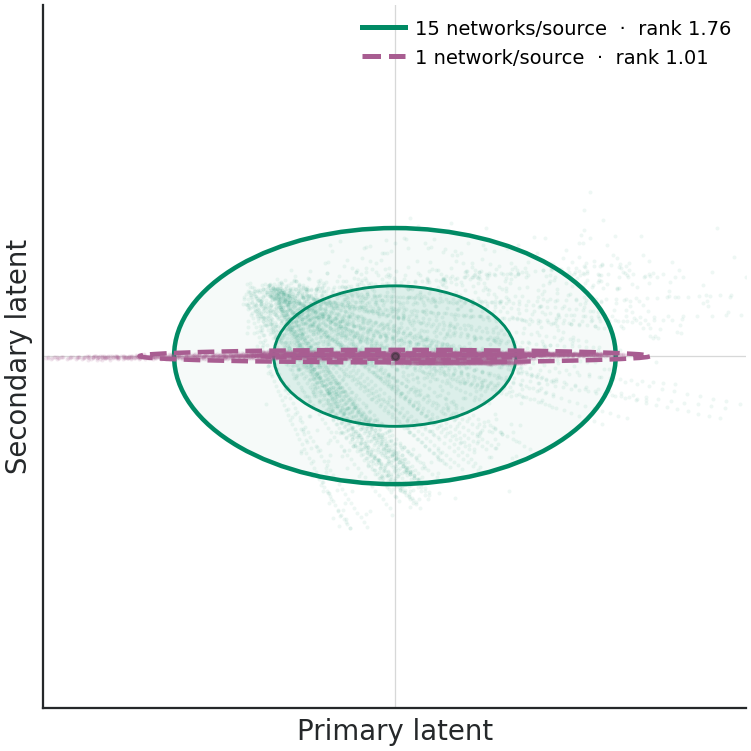

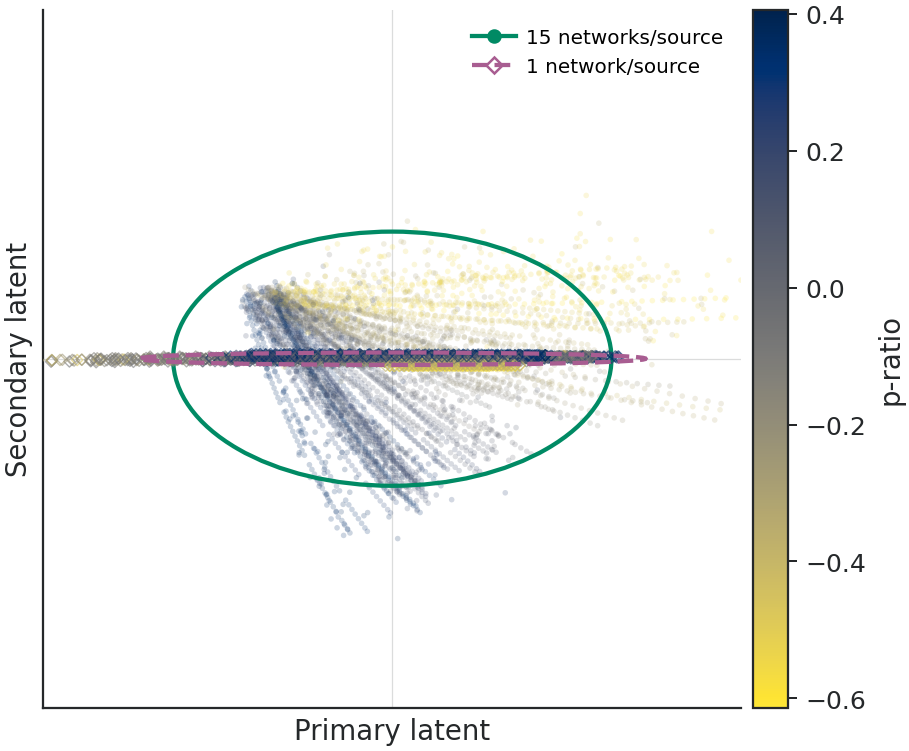

In [5]:
# Lightweight paper-figure cell: load cached coordinates only.
plt.rcParams.update({'figure.dpi': PAPER_DPI, 'savefig.dpi': 400})
_one_csv = PROJECT_ROOT/'notebooks'/'results'/'06_mixed_dataset_shared_latent_space_boxnorm'/'framewise_heldout_latents.csv'
_more_csv = OUTPUT/'heldout_latents_for_dimension.csv'
if not _one_csv.exists() or not _more_csv.exists():
    raise FileNotFoundError('Run the preceding latent-dimension cell once to create its cached coordinate tables.')
_source_labels = {key: spec['label'] for key,spec in DATASETS.items()}
_one = pd.read_csv(_one_csv)
_one = _one[_one.split.eq('test')].copy()
_one['dataset'] = _one.source.replace(_source_labels)
_one['final_p_ratio'] = _one.side_final_trajectory_p_ratio
_one = pd.concat([group[group.sim_idx.isin(np.sort(group.sim_idx.unique())[:30])] for _,group in _one.groupby('dataset',sort=False)],ignore_index=True)
_more = pd.read_csv(_more_csv)
comparison_frames = pd.concat([
    _one[['dataset','sim_idx','frame_idx','final_p_ratio','z0','z1']].assign(training_regime='1 network per source'),
    _more[['dataset','sim_idx','frame_idx','final_p_ratio','z0','z1']].assign(training_regime=f'{TRAIN_PER_SOURCE} networks per source'),
],ignore_index=True).replace([np.inf,-np.inf],np.nan).dropna(subset=['z0','z1'])

def _dimension_row(group,regime):
    values=group[['z0','z1']].to_numpy(float)
    centered=values-values.mean(0,keepdims=True)
    eigenvalues=np.linalg.eigvalsh(centered.T@centered/max(len(centered)-1,1))[::-1].clip(min=0)
    fractions=eigenvalues/max(eigenvalues.sum(),1e-12)
    return {'training_regime':regime,'dataset':'all datasets','effective_rank':np.exp(-(fractions*np.log(fractions+1e-12)).sum())}

dimension_comparison=pd.DataFrame([_dimension_row(group,regime) for regime,group in comparison_frames.groupby('training_regime',sort=False)])

from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

def aligned_latent_occupancy(frame):
    values=frame[['z0','z1']].to_numpy(float)
    centered=values-values.mean(axis=0,keepdims=True)
    covariance=np.cov(centered,rowvar=False)
    eigenvalues,eigenvectors=np.linalg.eigh(covariance)
    order=np.argsort(eigenvalues)[::-1]
    eigenvalues=eigenvalues[order].clip(min=0); eigenvectors=eigenvectors[:,order]
    total_scale=np.sqrt(max(eigenvalues.sum(),1e-12))
    return centered@eigenvectors/total_scale,eigenvalues/max(eigenvalues.sum(),1e-12)

occupancy_styles=[
    (f'{TRAIN_PER_SOURCE} networks per source',DIVERSE_TRAINING_COLOR,.065,'-',1),
    ('1 network per source',LIMITED_TRAINING_COLOR,.14,'--',2),
]
fig,ax=plt.subplots(figsize=PAPER_FIGSIZE,constrained_layout=True)
aligned_sets=[]; aligned_by_regime={}; fractions_by_regime={}
legend_handles=[]
for regime,color,point_alpha,line_style,zorder in occupancy_styles:
    aligned,fractions=aligned_latent_occupancy(comparison_frames[comparison_frames.training_regime.eq(regime)])
    aligned_sets.append(aligned)
    aligned_by_regime[regime]=aligned; fractions_by_regime[regime]=fractions
    sample=aligned[np.unique(np.linspace(0,len(aligned)-1,min(4500,len(aligned)),dtype=int))]
    rank=float(dimension_comparison[(dimension_comparison.training_regime.eq(regime)) & (dimension_comparison.dataset.eq('all datasets'))].effective_rank.iloc[0])
    label=(f'{TRAIN_PER_SOURCE} networks/source' if regime.startswith(str(TRAIN_PER_SOURCE)) else '1 network/source')+f'  ·  rank {rank:.2f}'
    ax.scatter(sample[:,0],sample[:,1],s=2.6,color=color,alpha=point_alpha,linewidth=0,rasterized=True,zorder=zorder)
    for probability,radius,fill_alpha in [(0.50,np.sqrt(1.386),.10),(0.90,np.sqrt(4.605),.035)]:
        width,height=2*radius*np.sqrt(fractions)
        ax.add_patch(Ellipse((0,0),width,height,facecolor=color,edgecolor='none',alpha=fill_alpha,zorder=zorder+.1))
        ax.add_patch(Ellipse((0,0),width,height,fill=False,edgecolor=color,linestyle=line_style,lw=1.15 if probability<.9 else 1.8,zorder=zorder+.2))
    legend_handles.append(Line2D([0],[0],color=color,linestyle=line_style,lw=2,label=label))
limit=float(np.quantile(np.abs(np.concatenate(aligned_sets)),.995))*1.05
ax.axhline(0,color=PAPER_COLORS['ink'],lw=.5,alpha=.18,zorder=0); ax.axvline(0,color=PAPER_COLORS['ink'],lw=.5,alpha=.18,zorder=0)
ax.scatter([0],[0],s=8,color=PAPER_COLORS['ink'],alpha=.45,zorder=5)
ax.set(xlim=(-limit,limit),ylim=(-limit,limit),xlabel='Primary latent',ylabel='Secondary latent')
ax.set_aspect('equal',adjustable='box'); ax.grid(False,which='both')
ax.tick_params(axis='both',which='both',length=0,labelbottom=False,labelleft=False)
ax.legend(handles=legend_handles,frameon=False,loc='upper right',fontsize=7.8,handlelength=2.2,handletextpad=.55,borderaxespad=.35)
plt.show()

# Same aligned plane, now retaining p-ratio as colour and model identity as shape.
all_pratio=comparison_frames.final_p_ratio.replace([np.inf,-np.inf],np.nan).dropna()
pratio_norm=plt.Normalize(all_pratio.quantile(.01),all_pratio.quantile(.99))
model_marks=[
    (f'{TRAIN_PER_SOURCE} networks per source','o','-',DIVERSE_TRAINING_COLOR,.20,5),
    ('1 network per source','D','--',LIMITED_TRAINING_COLOR,.58,7),
]
fig,ax=plt.subplots(figsize=PAPER_FIGSIZE,constrained_layout=True)
model_handles=[]
for regime,marker,line_style,outline,alpha,zorder in model_marks:
    regime_frame=comparison_frames[comparison_frames.training_regime.eq(regime)].reset_index(drop=True)
    aligned=aligned_by_regime[regime]
    max_points=4200 if marker=='o' else 1800
    sample_idx=np.unique(np.linspace(0,len(aligned)-1,min(max_points,len(aligned)),dtype=int))
    point_colors=plt.get_cmap('cividis_r')(pratio_norm(regime_frame.final_p_ratio.iloc[sample_idx].to_numpy(float)))
    if marker=='o':
        ax.scatter(aligned[sample_idx,0],aligned[sample_idx,1],facecolors=point_colors,edgecolors='none',marker=marker,s=5,alpha=alpha,rasterized=True,zorder=zorder)
    else:
        ax.scatter(aligned[sample_idx,0],aligned[sample_idx,1],facecolors='none',edgecolors=point_colors,marker=marker,s=10,alpha=alpha,linewidth=.55,rasterized=True,zorder=zorder)
    fractions=fractions_by_regime[regime]; radius=np.sqrt(4.605)
    ax.add_patch(Ellipse((0,0),2*radius*np.sqrt(fractions[0]),2*radius*np.sqrt(fractions[1]),fill=False,edgecolor=outline,linestyle=line_style,lw=1.7,zorder=zorder+.2))
    label=f'{TRAIN_PER_SOURCE} networks/source' if regime.startswith(str(TRAIN_PER_SOURCE)) else '1 network/source'
    model_handles.append(Line2D([0],[0],color=outline,linestyle=line_style,marker=marker,markerfacecolor=outline if marker=='o' else 'none',markeredgecolor=outline,markersize=4.8,lw=1.7,label=label))
ax.axhline(0,color=PAPER_COLORS['ink'],lw=.5,alpha=.16,zorder=0); ax.axvline(0,color=PAPER_COLORS['ink'],lw=.5,alpha=.16,zorder=0)
ax.set(xlim=(-limit,limit),ylim=(-limit,limit),xlabel='Primary latent',ylabel='Secondary latent')
ax.set_aspect('equal',adjustable='box'); ax.set_box_aspect(1); ax.grid(False,which='both')
ax.tick_params(axis='both',which='both',length=0,labelbottom=False,labelleft=False)
ax.legend(handles=model_handles,frameon=False,loc='upper right',fontsize=8,handlelength=2.2,handletextpad=.5)
fig.colorbar(plt.cm.ScalarMappable(norm=pratio_norm,cmap='cividis_r'),ax=ax,label='p-ratio',pad=.015,fraction=.045)
plt.show()



## Held-out p-ratio rollout

Held-out direct-autoencoder ceiling versus propagator R², alongside propagator position error. Early Real Reid uses a cumulative side-strain fit selected on validation data.


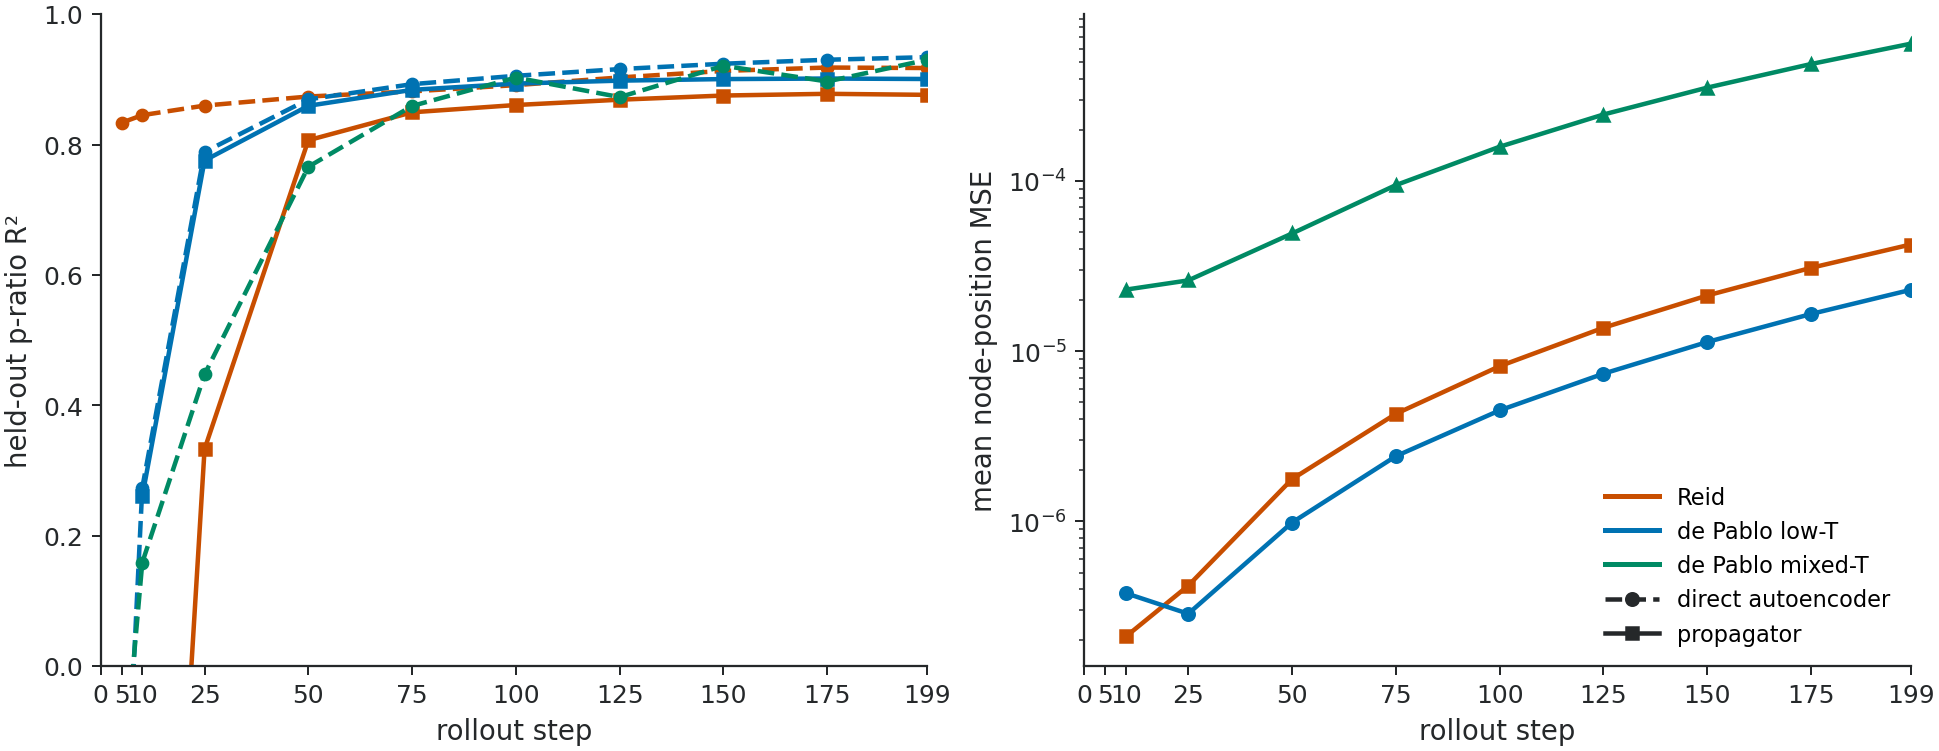

,source_family,rollout_steps,p_ratio_r2,pearson_r,position_mse,position_mse_std,n_networks
0,Reid,10,-1.23978,0.43533,0.00000,0.00000,72
1,Reid,25,0.33282,0.71754,0.00000,0.00000,72
2,Reid,50,0.80652,0.90979,0.00000,0.00000,72
3,Reid,75,0.84939,0.94427,0.00000,0.00000,72
4,Reid,100,0.86056,0.95366,0.00001,0.00001,72
5,Reid,125,0.86871,0.95626,0.00001,0.00001,72
6,Reid,150,0.87511,0.95638,0.00002,0.00001,72
7,Reid,175,0.87775,0.95553,0.00003,0.00002,72
8,Reid,199,0.87616,0.95435,0.00004,0.00003,72
9,de Pablo low-T,10,0.26048,0.77951,0.00000,0.00000,170


Held-out shared rollout at frame 100.


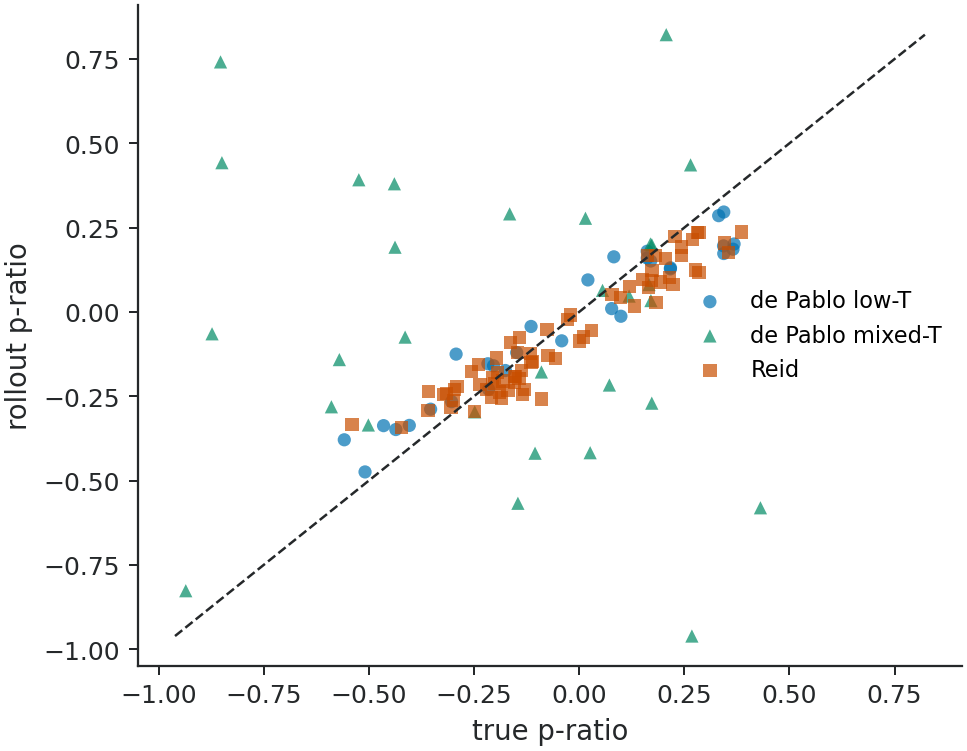

Held-out shared rollout at frame 150.


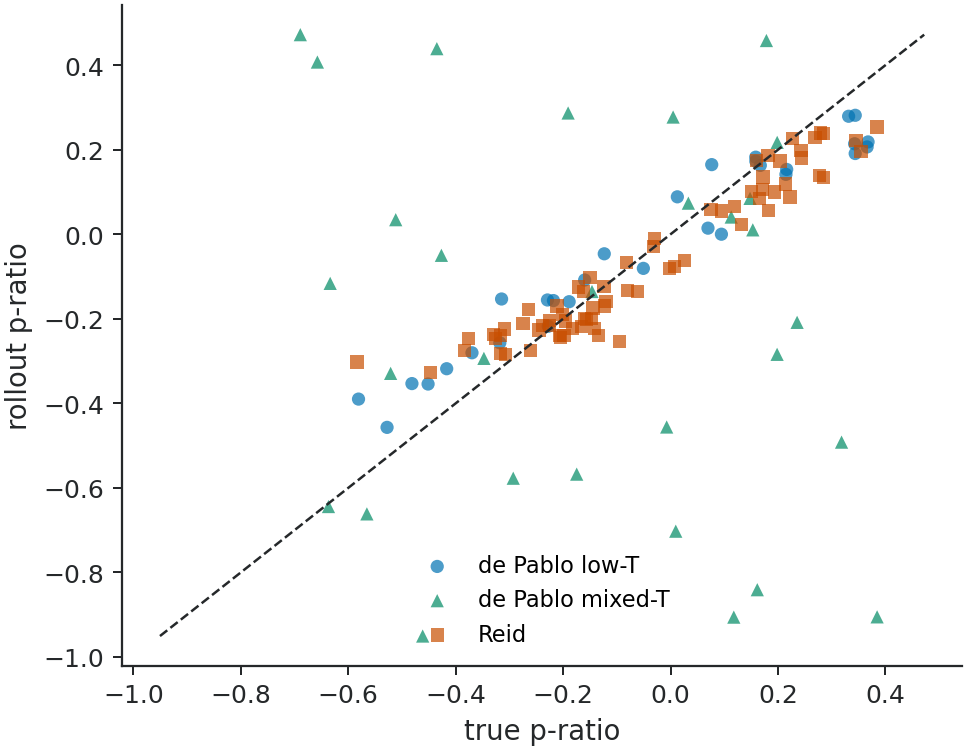

In [6]:
SOURCE_LABELS = {key: spec['label'] for key,spec in DATASETS.items()}
SOURCE_STYLES = {'Reid': ('reid','s'), 'de Pablo low-T': ('depablo_low_temp','o'), 'de Pablo mixed-T': ('depablo_mixed_temp','^')}
rollout_rows = label_evaluation_sources(
    rollout_raw, SOURCE_LABELS,
)
rollout_rows.to_csv(OUTPUT/'heldout_rollout_rows_by_source.csv', index=False)
summary_rows = []
for (source_family, step), group in rollout_rows.groupby(['source_family','rollout_steps']):
    valid = group[['true_p_ratio','pred_p_ratio']].dropna()
    position_mse = group.final_pos_mse.replace([np.inf,-np.inf],np.nan).dropna()
    summary_rows.append({'source_family': source_family, 'rollout_steps': int(step), 'p_ratio_r2': r2_score(valid.true_p_ratio, valid.pred_p_ratio), 'pearson_r': pearson_r(valid.true_p_ratio, valid.pred_p_ratio), 'position_mse': position_mse.mean(), 'position_mse_std': position_mse.std(ddof=1), 'n_networks': len(valid)})
rollout_summary = pd.DataFrame(summary_rows)
rollout_summary.to_csv(OUTPUT/'heldout_pratio_rollout_by_source.csv', index=False)

# One paper-facing comparison: reconstruction ceiling versus autonomous propagation.
ae_rows = label_evaluation_sources(
    autoencoder_raw, SOURCE_LABELS,
)
ae_rows = ae_rows[ae_rows.source_family.isin(SOURCE_STYLES)].copy()
ceiling_comparison_rows = []
for representation, frame in [('direct autoencoder', ae_rows), ('propagator', rollout_rows)]:
    for (source_family, step), group in frame.groupby(['source_family','rollout_steps']):
        valid = group[['true_p_ratio','pred_p_ratio']].replace([np.inf,-np.inf],np.nan).dropna()
        ceiling_comparison_rows.append({
            'representation': representation, 'source_family': source_family,
            'rollout_steps': int(step),
            'p_ratio_r2': r2_score(valid.true_p_ratio, valid.pred_p_ratio) if len(valid) >= 2 else np.nan,
            'n_networks': len(valid),
        })
ceiling_comparison = pd.DataFrame(ceiling_comparison_rows)
ceiling_comparison.to_csv(OUTPUT/'heldout_ae_ceiling_vs_propagator_by_source.csv', index=False)

print('Held-out direct-autoencoder ceiling versus propagator R², alongside propagator position error. Early Real Reid uses a cumulative side-strain fit selected on validation data.')
fig, axes = plt.subplots(1, 2, figsize=PAPER_WIDE_FIGSIZE, constrained_layout=True)
REPRESENTATION_STYLES = {
    'direct autoencoder': {'linestyle': '--', 'marker': 'o'},
    'propagator': {'linestyle': '-', 'marker': 's'},
}
for source_family in SOURCE_STYLES:
    key, _ = SOURCE_STYLES[source_family]
    color = dataset_color(key)
    for representation, representation_style in REPRESENTATION_STYLES.items():
        group = ceiling_comparison[
            ceiling_comparison.source_family.eq(source_family)
            & ceiling_comparison.representation.eq(representation)
        ].sort_values('rollout_steps')
        axes[0].plot(group.rollout_steps, group.p_ratio_r2, color=color, lw=1.8, ms=4.5, **representation_style)
for source_family, group in rollout_summary.groupby('source_family', sort=False):
    key, marker = SOURCE_STYLES[source_family]
    group = group.sort_values('rollout_steps')
    axes[1].plot(group.rollout_steps, group.position_mse, color=dataset_color(key), marker=marker, lw=1.8, ms=5)
axes[0].axhline(0, color=PAPER_COLORS['slate'], lw=.8)
style_axes(axes[0], xlabel='rollout step', ylabel='held-out p-ratio R²', legend=False)
style_axes(axes[1], xlabel='rollout step', ylabel='mean node-position MSE', legend=False)
axes[0].set_ylim(0, 1)
axes[1].set_yscale('log')
for ax in axes:
    ax.set_xlim(0, max(PLOT_ROLLOUT_STEPS))
    ax.set_xticks([0, *PLOT_ROLLOUT_STEPS])
from matplotlib.lines import Line2D
dataset_handles = [Line2D([0],[0], color=dataset_color(SOURCE_STYLES[label][0]), lw=2, label=label) for label in SOURCE_STYLES]
representation_handles = [Line2D([0],[0], color=PAPER_COLORS['ink'], lw=1.8, label=representation, **representation_style) for representation, representation_style in REPRESENTATION_STYLES.items()]
axes[1].legend(handles=[*dataset_handles, *representation_handles], loc='lower right', frameon=False, handlelength=2.4)
plt.show()
display(rollout_summary.round(5))

for step in [100,150]:
    selected = rollout_rows[rollout_rows.rollout_steps.eq(step)].dropna(subset=['true_p_ratio','pred_p_ratio'])
    print(f'Held-out shared rollout at frame {step}.')
    fig, ax = plt.subplots(figsize=PAPER_FIGSIZE, constrained_layout=True)
    for source_family, group in selected.groupby('source_family', sort=False):
        key, marker = SOURCE_STYLES[source_family]
        ax.scatter(group.true_p_ratio, group.pred_p_ratio, s=28, alpha=.7, marker=marker, color=dataset_color(key), edgecolor='none', label=source_family)
    limits=np.r_[selected.true_p_ratio,selected.pred_p_ratio]; lo,hi=np.nanmin(limits),np.nanmax(limits)
    ax.plot([lo,hi],[lo,hi],'--',color=PAPER_COLORS['ink'],lw=1)
    style_axes(ax,xlabel='true p-ratio',ylabel='rollout p-ratio',legend=True)
    plt.show()